In [1]:
import obd
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt


In [10]:
print("Connecting to OBD-II adapter...")
connection = obd.OBD() 

Connecting to OBD-II adapter...


In [13]:
def read_in_loop(connction, duration=60):
    if connection.status() == obd.OBDStatus.NOT_CONNECTED:
        print("Error: Could not find an OBD-II adapter. Check your COM port.")
        return pd.DataFrame()  # Return empty DataFrame if not connected              

    cmd_rpm = obd.commands.RPM
    cmd_speed = obd.commands.SPEED
    
    data = []
    start_time = time.time()
    
    while time.time() - start_time < duration:
        rpm_response = connection.query(cmd_rpm)
        speed_response = connection.query(cmd_speed)
        
        if not rpm_response.is_null() and not speed_response.is_null():
            data.append({
                "timestamp": time.time(),
                "rpm": rpm_response.value.magnitude,
                "speed": speed_response.value.magnitude
            })
        
        time.sleep(0.15)  # Read every second

    
    
    return pd.DataFrame(data)

In [14]:
readings_df = read_in_loop(connection, duration=60)
print(readings_df.head())

      timestamp      rpm  speed
0  1.775915e+09  6528.00  102.0
1  1.775915e+09  1997.50  102.0
2  1.775915e+09  1992.75  101.0
3  1.775915e+09  1978.25  101.0
4  1.775915e+09  1970.25  100.0


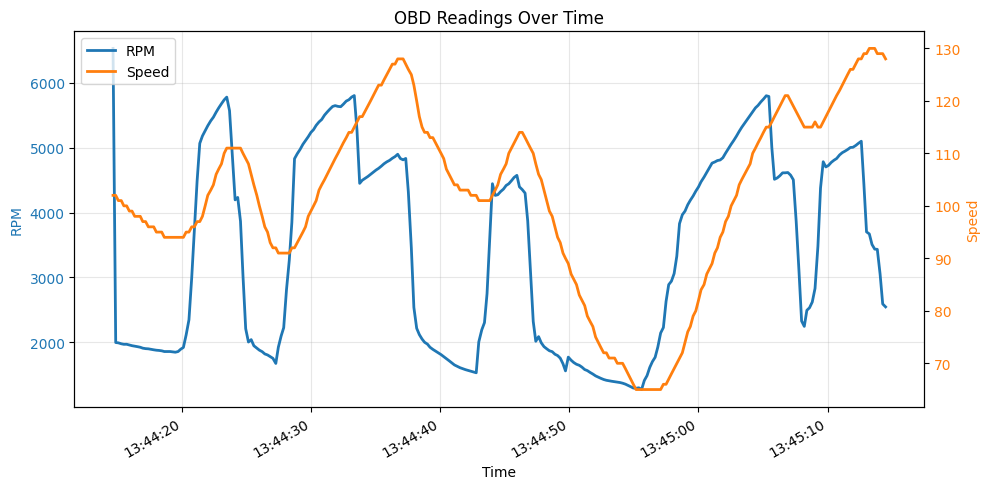

In [15]:
if readings_df.empty:
    print("No readings captured. Check connection and try again.")
else:
    plot_df = readings_df.copy()
    plot_df["timestamp"] = pd.to_datetime(plot_df["timestamp"], unit="s")
    plot_df = plot_df.set_index("timestamp")

    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(plot_df.index, plot_df["rpm"], color="tab:blue", label="RPM", linewidth=2)
    ax1.set_ylabel("RPM", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    ax2.plot(plot_df.index, plot_df["speed"], color="tab:orange", label="Speed", linewidth=2)
    ax2.set_ylabel("Speed", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    ax1.set_title("OBD Readings Over Time")
    ax1.set_xlabel("Time")
    fig.autofmt_xdate()
    ax1.grid(True, alpha=0.3)

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

    plt.tight_layout()
    plt.show()

In [16]:
#save pandas dataframe to pickle
readings_df.to_pickle("obd_readings4.pkl")

In [17]:
connection.close()